[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leoe21/machine_learning_fundamentals/blob/main/02_unidad/02_02_regresion_polinomial_multivariable_california.ipynb)


# Regresion polinomial multivariable (California Housing)

**Asignatura:** Fundamentos de aprendizaje automatico / analitica

## Objetivo

- Entrenar un modelo de regresion polinomial con **varias variables predictoras**.
- Ajustar hiperparametros con validacion cruzada en train (`degree` y `alpha`).
- Evaluar una sola vez en test y revisar metricas, sobreajuste y supuestos basicos.

## Formula base (caso multivariable)

En regresion polinomial multivariable con variables $x_1, x_2, \ldots, x_p$, el modelo lineal se entrena sobre terminos transformados:

$$
\hat{y} = \beta_0 + \sum_{j=1}^{p} \beta_j x_j + \sum_{j=1}^{p} \beta_{jj} x_j^2 + \sum_{j<k} \beta_{jk} x_jx_k + \cdots
$$

- `degree=1`: solo terminos lineales.
- `degree=2`: agrega cuadrados e interacciones.
- `degree=3`: agrega terminos cubicos y combinaciones de grado 3.

Aunque la expresion parece no lineal en las variables originales, sigue siendo un modelo **lineal en coeficientes**.

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

---
## 1. Carga de datos reales y diccionario de variables

Usamos directamente `fetch_california_housing` de `sklearn` para mantener el notebook simple y totalmente reproducible.

In [66]:
cali = fetch_california_housing(as_frame=True)
df = cali.frame.copy()
df = df.rename(columns={"MedHouseVal": "median_house_value"})
print("Fuente: sklearn.fetch_california_housing")

display(df.head())
print("Forma:", df.shape)

diccionario = pd.DataFrame(
    {
        "variable": [
            "MedInc",
            "HouseAge",
            "AveRooms",
            "AveBedrms",
            "Population",
            "AveOccup",
            "Latitude",
            "Longitude",
            "median_house_value",
        ],
        "descripcion": [
            "Ingreso medio del hogar (decenas de miles de USD)",
            "Edad media de las viviendas (años)",
            "Promedio de habitaciones por hogar",
            "Promedio de dormitorios por hogar",
            "Poblacion del bloque censal",
            "Promedio de ocupantes por hogar",
            "Latitud",
            "Longitud",
            "Valor medio de vivienda (objetivo, en cientos de miles de USD)",
        ],
    }
)

print("Diccionario de variables:")
display(diccionario)

Fuente: sklearn.fetch_california_housing


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Forma: (20640, 9)
Diccionario de variables:


,variable,descripcion
0,MedInc,Ingreso medio del hogar (decenas de miles de USD)
1,HouseAge,Edad media de las viviendas (años)
2,AveRooms,Promedio de habitaciones por hogar
3,AveBedrms,Promedio de dormitorios por hogar
4,Population,Poblacion del bloque censal
5,AveOccup,Promedio de ocupantes por hogar
6,Latitude,Latitud
7,Longitude,Longitud
8,median_house_value,"Valor medio de vivienda (objetivo, en cientos ..."


## 2. EDA breve

Usamos 5 predictores numericos para evitar una explosion de columnas en la expansion polinomial, pero manteniendo el caso claramente multivariable.

Variables elegidas: ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude']
Objetivo: median_house_value
Nulos por columna:


,n_missing
MedInc,0
HouseAge,0
AveRooms,0
AveOccup,0
Latitude,0
median_house_value,0


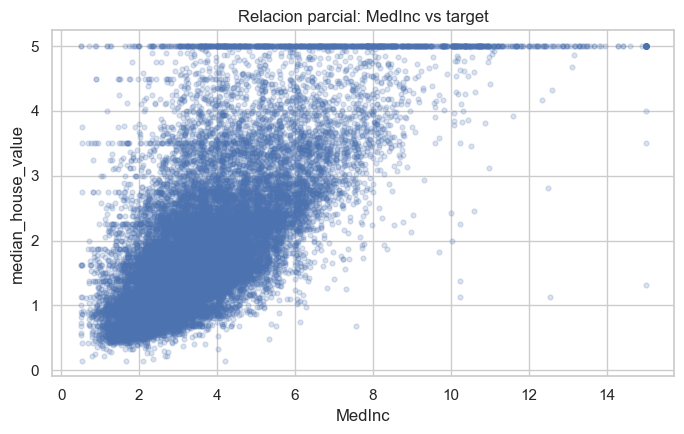

In [67]:
feature_cols = ["MedInc", "HouseAge", "AveRooms", "AveOccup", "Latitude"]
target_col = "median_house_value"

missing_features = [c for c in feature_cols if c not in df.columns]
if missing_features:
    raise ValueError(f"No se encontraron columnas requeridas: {missing_features}")
if target_col not in df.columns:
    raise ValueError(f"No se encontro la variable objetivo: {target_col}")

eda = df[feature_cols + [target_col]].copy()
print("Variables elegidas:", feature_cols)
print("Objetivo:", target_col)
print("Nulos por columna:")
display(eda.isna().sum().to_frame("n_missing"))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(eda["MedInc"], eda[target_col], alpha=0.2, s=12)
ax.set_xlabel("MedInc")
ax.set_ylabel(target_col)
ax.set_title("Relacion parcial: MedInc vs target")
plt.tight_layout()
plt.show()

---
## 3. Train/Test

No evaluamos solo en train porque eso da una estimacion optimista. Reservar test permite medir generalizacion en datos no vistos.

In [68]:
work = eda.dropna().copy()
X = work[feature_cols]
y = work[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (15480, 5) | Test: (5160, 5)


## 4. Visualizacion didactica de `PolynomialFeatures`

Antes de entrenar, veamos **que hace exactamente** la transformacion polinomial en un ejemplo pequeno.

Tomamos 2 variables (`MedInc` y `HouseAge`) y aplicamos grado 2 para observar las nuevas columnas generadas (`x^2` e interacciones `x1*x2`).

In [69]:
demo_cols = ["MedInc", "HouseAge"]
X_demo = X_train[demo_cols].head(5).copy()

poly_demo = PolynomialFeatures(degree=2, include_bias=False)
X_demo_poly = poly_demo.fit_transform(X_demo)
feature_names = poly_demo.get_feature_names_out(demo_cols)

df_demo_poly = pd.DataFrame(X_demo_poly, columns=feature_names, index=X_demo.index)

print("Ejemplo original (2 variables):")
display(X_demo)

print("Transformacion polinomial (degree=2):")
display(df_demo_poly)

print("Columnas generadas:")
print(list(feature_names))

Ejemplo original (2 variables):


,MedInc,HouseAge
8158,4.2143,37.0
18368,5.3468,42.0
19197,3.9191,36.0
3746,6.3703,32.0
13073,2.3684,17.0


Transformacion polinomial (degree=2):


,MedInc,HouseAge,MedInc^2,MedInc HouseAge,HouseAge^2
8158,4.2143,37.0,17.760324,155.9291,1369.0
18368,5.3468,42.0,28.588270,224.5656,1764.0
19197,3.9191,36.0,15.359345,141.0876,1296.0
3746,6.3703,32.0,40.580722,203.8496,1024.0
13073,2.3684,17.0,5.609319,40.2628,289.0


Columnas generadas:
['MedInc', 'HouseAge', 'MedInc^2', 'MedInc HouseAge', 'HouseAge^2']


## 4.2 Estandarizacion vs normalizacion

- **Estandarizacion (`StandardScaler`)**: transforma cada variable como

$$
z = \frac{x - \mu}{\sigma}
$$

donde $\mu$ es la media y $\sigma$ la desviacion estandar (estimadas en train).

- **Normalizacion (`MinMaxScaler`)**: transforma cada variable como

$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

llevandola tipicamente al rango $[0, 1]$.

**Regla correcta para evitar fuga de informacion:**

- `fit` del escalador: **solo con train**.
- `transform`: train y test con ese mismo escalador ya ajustado en train.

En este notebook elegimos **estandarizacion** porque, tras `PolynomialFeatures`, las columnas quedan en escalas muy distintas y los modelos regularizados (Ridge/Lasso/Elastic Net) suelen comportarse mejor cuando las variables estan centradas y comparables en varianza.

In [70]:
from sklearn.preprocessing import MinMaxScaler

cols_demo_scale = ["MedInc", "HouseAge", "AveRooms"]
X_scale_train = X_train[cols_demo_scale].copy()
X_scale_test = X_test[cols_demo_scale].copy()

std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()

# Regla metodologica: fit SOLO en train
X_std_train = std_scaler.fit_transform(X_scale_train)
X_std_test = std_scaler.transform(X_scale_test)

X_mm_train = mm_scaler.fit_transform(X_scale_train)
X_mm_test = mm_scaler.transform(X_scale_test)

df_scale_compare = pd.DataFrame(
    {
        "variable": cols_demo_scale,
        "media_original_train": X_scale_train.mean().values,
        "std_original_train": X_scale_train.std(ddof=0).values,
        "media_std_train": X_std_train.mean(axis=0),
        "std_std_train": X_std_train.std(axis=0),
        "min_mm_train": X_mm_train.min(axis=0),
        "max_mm_train": X_mm_train.max(axis=0),
        "media_std_test": X_std_test.mean(axis=0),
        "min_mm_test": X_mm_test.min(axis=0),
        "max_mm_test": X_mm_test.max(axis=0),
    }
)

print("Comparacion de transformaciones (fit en train, transform en train/test):")
display(df_scale_compare.round(4))

print("Nota: en test, la media estandarizada no tiene por que ser 0 ni el rango MinMax exactamente [0,1], porque el ajuste se hizo solo con train.")

Comparacion de transformaciones (fit en train, transform en train/test):


,variable,media_original_train,std_original_train,media_std_train,std_std_train,min_mm_train,max_mm_train,media_std_test,min_mm_test,max_mm_test
0,MedInc,3.8783,1.9037,0.0,1.0,0.0,1.0,-0.0161,0.0000,1.0000
1,HouseAge,28.5960,12.6109,-0.0,1.0,0.0,1.0,0.0138,0.0000,1.0000
2,AveRooms,5.4356,2.4216,-0.0,1.0,0.0,1.0,-0.0109,-0.0003,0.9335


Nota: en test, la media estandarizada no tiene por que ser 0 ni el rango MinMax exactamente [0,1], porque el ajuste se hizo solo con train.


---
## 5. Pipeline y calibracion de hiperparametros (Ridge, Lasso y Elastic Net)

Escalamos **despues** de `PolynomialFeatures` porque las potencias e interacciones quedan en escalas muy diferentes.

Comparamos tres regularizaciones:

- **Ridge (L2):** encoge coeficientes de forma estable.
- **Lasso (L1):** puede llevar coeficientes exactamente a 0.
- **Elastic Net (L1 + L2):** equilibrio entre estabilidad y sparsidad.

La seleccion de hiperparametros se hace con CV en train (test no participa).

In [71]:
search_spaces = {
    "Ridge": {
        "model": Ridge(),
        "param_grid": {
            "poly__degree": [1, 2, 3],
            "model__alpha": np.logspace(-3, 3, 13),
        },
    },
    "Lasso": {
        "model": Lasso(max_iter=10000),
        "param_grid": {
            "poly__degree": [1, 2, 3],
            "model__alpha": np.logspace(-4, 1, 10),
        },
    },
    "ElasticNet": {
        "model": ElasticNet(max_iter=10000),
        "param_grid": {
            "poly__degree": [1, 2, 3],
            "model__alpha": np.logspace(-4, 1, 10),
            "model__l1_ratio": [0.2, 0.5, 0.8],
        },
    },
}

def evaluate_model(name, estimator, params):
    pipe = Pipeline(
        steps=[
            ("poly", PolynomialFeatures(include_bias=False)),
            ("scale", StandardScaler()),
            ("model", estimator),
        ]
    )

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=params,
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)

    best = grid.best_estimator_
    ytr_hat = best.predict(X_train)
    yte_hat = best.predict(X_test)

    row = {
        "modelo": name,
        "best_params": grid.best_params_,
        "cv_RMSE": np.sqrt(-grid.best_score_),
        "train_RMSE": np.sqrt(mean_squared_error(y_train, ytr_hat)),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, yte_hat)),
        "train_R2": r2_score(y_train, ytr_hat),
        "test_R2": r2_score(y_test, yte_hat),
    }
    return row, best

results = []
best_estimators = {}
for model_name, spec in search_spaces.items():
    row, est = evaluate_model(model_name, spec["model"], spec["param_grid"])
    results.append(row)
    best_estimators[model_name] = est

model_results_df = pd.DataFrame(results).sort_values("cv_RMSE").reset_index(drop=True)
display(model_results_df)

best_cv_name = model_results_df.loc[0, "modelo"]
best_cv_model = best_estimators[best_cv_name]

best_degree = best_cv_model.named_steps["poly"].degree
poly_tmp = PolynomialFeatures(degree=best_degree, include_bias=False)
poly_tmp.fit(X_train)
print("Modelo seleccionado por CV:", best_cv_name)
print("Numero de features originales:", X_train.shape[1])
print("Numero de features polinomiales (mejor degree de ese modelo):", poly_tmp.n_output_features_)

,modelo,best_params,cv_RMSE,train_RMSE,test_RMSE,train_R2,test_R2
0,ElasticNet,"{'model__alpha': 0.05994842503189409, 'model__...",0.799762,0.797304,0.795270,0.523580,0.522033
1,Lasso,"{'model__alpha': 0.016681005372000592, 'poly__...",0.803130,0.800752,0.798300,0.519451,0.518384
2,Ridge,"{'model__alpha': 316.22776601683796, 'poly__de...",0.804082,0.800004,0.797044,0.520348,0.519899


Modelo seleccionado por CV: ElasticNet
Numero de features originales: 5
Numero de features polinomiales (mejor degree de ese modelo): 55


---
## 6. Comparacion de resultados: Ridge vs Lasso vs Elastic Net

Tabla de comparacion en train/test usando, para cada familia, su mejor configuracion segun CV en train.

In [72]:
cols_summary = [
    "modelo",
    "best_params",
    "cv_RMSE",
    "train_RMSE",
    "test_RMSE",
    "train_R2",
    "test_R2",
]

display(model_results_df[cols_summary].copy().round(4))

print("Lectura rapida:")
print("- Menor test_RMSE y mayor test_R2 suelen indicar mejor generalizacion.")
print("- Si train_RMSE << test_RMSE (o train_R2 >> test_R2), hay senales de sobreajuste.")

,modelo,best_params,cv_RMSE,train_RMSE,test_RMSE,train_R2,test_R2
0,ElasticNet,"{'model__alpha': 0.05994842503189409, 'model__...",0.7998,0.7973,0.7953,0.5236,0.5220
1,Lasso,"{'model__alpha': 0.016681005372000592, 'poly__...",0.8031,0.8008,0.7983,0.5195,0.5184
2,Ridge,"{'model__alpha': 316.22776601683796, 'poly__de...",0.8041,0.8000,0.7970,0.5203,0.5199


Lectura rapida:
- Menor test_RMSE y mayor test_R2 suelen indicar mejor generalizacion.
- Si train_RMSE << test_RMSE (o train_R2 >> test_R2), hay senales de sobreajuste.


### Visualizacion de terminos polinomiales generados

Para que sea mas claro: el numero de features polinomiales es la cantidad total de terminos creados por `PolynomialFeatures` (variables originales + potencias + interacciones).

In [73]:
best_degree = best_cv_model.named_steps["poly"].degree
poly_tmp = PolynomialFeatures(degree=best_degree, include_bias=False)
poly_tmp.fit(X_train)
feature_names_poly = poly_tmp.get_feature_names_out(X_train.columns)

print("Modelo seleccionado por CV:", best_cv_name)
print("Degree seleccionado:", best_degree)
print("Numero total de terminos polinomiales:", len(feature_names_poly))

print("\nPrimeros 20 terminos generados:")
for i, name in enumerate(feature_names_poly[:20], start=1):
    print(f"{i:>2}. {name}")

if len(feature_names_poly) > 20:
    print(f"\n... y {len(feature_names_poly) - 20} terminos adicionales.")

display(
    pd.DataFrame(
        {
            "indice": np.arange(1, len(feature_names_poly) + 1),
            "termino_polinomial": feature_names_poly,
        }
    ).head(30)
)

Modelo seleccionado por CV: ElasticNet
Degree seleccionado: 3
Numero total de terminos polinomiales: 55

Primeros 20 terminos generados:
 1. MedInc
 2. HouseAge
 3. AveRooms
 4. AveOccup
 5. Latitude
 6. MedInc^2
 7. MedInc HouseAge
 8. MedInc AveRooms
 9. MedInc AveOccup
10. MedInc Latitude
11. HouseAge^2
12. HouseAge AveRooms
13. HouseAge AveOccup
14. HouseAge Latitude
15. AveRooms^2
16. AveRooms AveOccup
17. AveRooms Latitude
18. AveOccup^2
19. AveOccup Latitude
20. Latitude^2

... y 35 terminos adicionales.


,indice,termino_polinomial
0,1,MedInc
1,2,HouseAge
2,3,AveRooms
3,4,AveOccup
4,5,Latitude
5,6,MedInc^2
6,7,MedInc HouseAge
7,8,MedInc AveRooms
8,9,MedInc AveOccup
9,10,MedInc Latitude


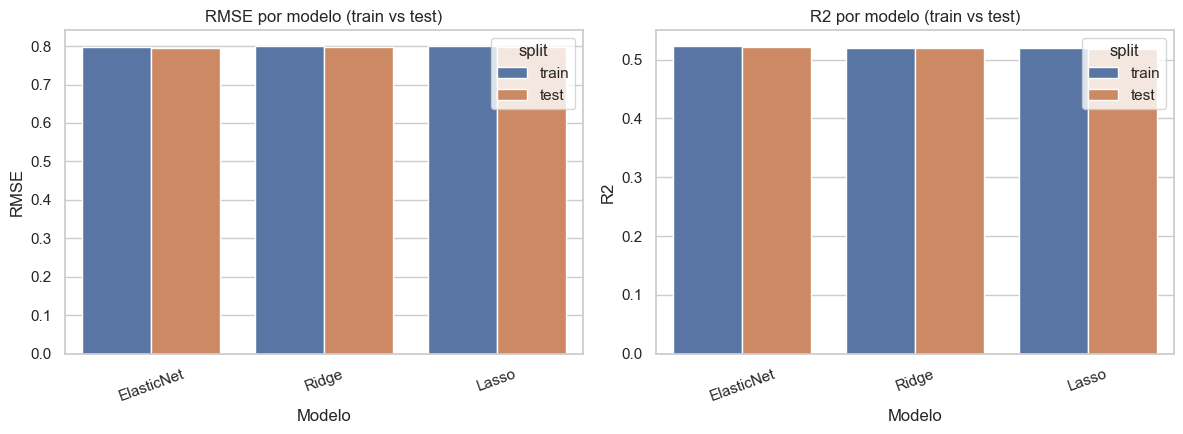

In [74]:
order_models = model_results_df.sort_values("test_RMSE")["modelo"].tolist()

plot_rmse = model_results_df.melt(
    id_vars=["modelo"],
    value_vars=["train_RMSE", "test_RMSE"],
    var_name="split",
    value_name="RMSE",
)
plot_rmse["split"] = plot_rmse["split"].str.replace("_RMSE", "", regex=False)

plot_r2 = model_results_df.melt(
    id_vars=["modelo"],
    value_vars=["train_R2", "test_R2"],
    var_name="split",
    value_name="R2",
)
plot_r2["split"] = plot_r2["split"].str.replace("_R2", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=plot_rmse, x="modelo", y="RMSE", hue="split", order=order_models, ax=axes[0])
axes[0].set_title("RMSE por modelo (train vs test)")
axes[0].set_xlabel("Modelo")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=plot_r2, x="modelo", y="R2", hue="split", order=order_models, ax=axes[1])
axes[1].set_title("R2 por modelo (train vs test)")
axes[1].set_xlabel("Modelo")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [75]:
best_test_idx = model_results_df["test_RMSE"].idxmin()
best_test_row = model_results_df.loc[best_test_idx]

gen_gap = best_test_row["test_RMSE"] - best_test_row["train_RMSE"]
r2_gap = best_test_row["train_R2"] - best_test_row["test_R2"]

print("Conclusiones de la seccion 6:")
print(
    f"1) Mejor modelo por test_RMSE: {best_test_row['modelo']} "
    f"(test_RMSE={best_test_row['test_RMSE']:.4f}, test_R2={best_test_row['test_R2']:.4f})."
)
print(
    f"2) Brecha de generalizacion (test_RMSE - train_RMSE): {gen_gap:.4f}; "
    f"brecha en R2 (train_R2 - test_R2): {r2_gap:.4f}."
)
if gen_gap > 0.08 or r2_gap > 0.08:
    print("3) Interpretacion: hay senales apreciables de sobreajuste.")
else:
    print("3) Interpretacion: no se observan senales fuertes de sobreajuste.")

print("4) CV y test son cercanos en magnitud, lo que sugiere seleccion de hiperparametros razonablemente estable.")

Conclusiones de la seccion 6:
1) Mejor modelo por test_RMSE: ElasticNet (test_RMSE=0.7953, test_R2=0.5220).
2) Brecha de generalizacion (test_RMSE - train_RMSE): -0.0020; brecha en R2 (train_R2 - test_R2): 0.0015.
3) Interpretacion: no se observan senales fuertes de sobreajuste.
4) CV y test son cercanos en magnitud, lo que sugiere seleccion de hiperparametros razonablemente estable.


## 7. Prediccion vs realidad (test)

En multivariable no hay una curva 2D unica. Este grafico ayuda a validar si las predicciones se acercan a la diagonal ideal.

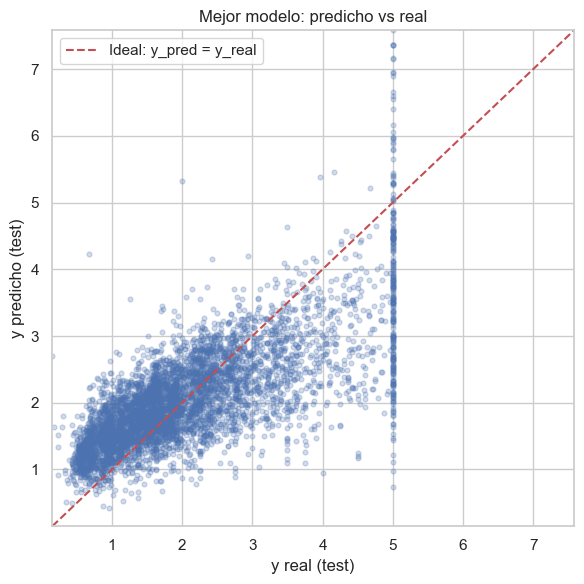

In [76]:
y_test_hat = best_cv_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_test_hat, alpha=0.25, s=12)
lims = [min(y_test.min(), y_test_hat.min()), max(y_test.max(), y_test_hat.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Ideal: y_pred = y_real")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("y real (test)")
ax.set_ylabel("y predicho (test)")
ax.set_title("Mejor modelo: predicho vs real")
ax.legend()
plt.tight_layout()
plt.show()

### Complemento interpretativo de la seccion 7

A continuacion agregamos una lectura visual y un resumen numerico del grafico `y_real` vs `y_pred` para apoyar la interpretacion en clase.

### Como leer este grafico

- Cuanto mas cerca este un punto de la diagonal roja, menor error de prediccion.
- Si para valores altos de `y_real` los puntos quedan por debajo de la diagonal, el modelo tiende a **subestimar** esos casos.
- La columna vertical alrededor de `y_real ~ 5` es esperable en este dataset: la variable objetivo esta truncada en su tope superior (censura en el precio).

In [77]:
# Resumen numerico de la seccion 7
res_test = y_test_hat - y_test.values
mae_test = np.mean(np.abs(res_test))
rmse_test = np.sqrt(np.mean(res_test**2))

high_mask = y_test.values >= 4.5
if np.any(high_mask):
    high_bias = np.mean(y_test_hat[high_mask] - y_test.values[high_mask])
else:
    high_bias = np.nan

print("Conclusiones seccion 7:")
print(f"- MAE en test: {mae_test:.4f}")
print(f"- RMSE en test: {rmse_test:.4f}")
if not np.isnan(high_bias):
    print(f"- Sesgo promedio en valores altos (y_real >= 4.5): {high_bias:.4f}")
    if high_bias < 0:
        print("  Interpretacion: hay tendencia a subestimar viviendas de alto valor.")
    else:
        print("  Interpretacion: no se observa subestimacion promedio en ese tramo alto.")
else:
    print("- No hubo suficientes casos en tramo alto para evaluar sesgo.")

Conclusiones seccion 7:
- MAE en test: 0.5944
- RMSE en test: 0.7953
- Sesgo promedio en valores altos (y_real >= 4.5): -1.3804
  Interpretacion: hay tendencia a subestimar viviendas de alto valor.


---
## 8. Supuestos basicos (residuos en train)

### 8.1 Que son los supuestos

En regresion lineal (incluyendo la version polinomial), asumimos ciertas condiciones sobre los errores (residuos) para que el modelo sea interpretable y estable:

1. **Relacion funcional adecuada**: el modelo captura razonablemente la forma de la relacion (en este caso, mediante terminos polinomiales).
2. **Media del error cercana a 0**: en promedio, el modelo no deberia sesgar sistematicamente hacia arriba o abajo.
3. **Homoscedasticidad**: la variabilidad del error deberia ser parecida a lo largo del rango de predicciones.
4. **Normalidad aproximada de residuos**: especialmente relevante para inferencia estadistica clasica (intervalos y pruebas).
5. **Independencia de errores**: importante cuando hay estructura temporal o espacial fuerte.

### 8.2 Por que es importante validarlos

- Ayuda a detectar **sesgo del modelo** y problemas de especificacion.
- Mejora la confianza en la **interpretacion de metricas** y coeficientes.
- Evita decisiones de negocio basadas en modelos que funcionan mal en ciertos segmentos.

### 8.3 Como los validamos aqui

En este notebook usamos dos diagnosticos visuales sobre train:

- **Residuos vs ajustados**: si aparece patron curvo o forma de abanico, puede haber problema de forma funcional u homoscedasticidad.
- **Q-Q plot de residuos**: compara cuantiles observados vs cuantiles normales teoricos para evaluar normalidad aproximada.

### 8.4 Como interpretar

- **Bueno**: nube sin patron claro en residuos vs ajustados, y Q-Q razonablemente cercano a la linea.
- **Alerta**: curvatura marcada (falta de terminos), abanico (heteroscedasticidad), colas muy pesadas o asimetria fuerte en Q-Q.

### 8.5 Que pasa si un supuesto no se cumple

No siempre invalida el uso predictivo, pero cambia la lectura del modelo:

- Si falla forma funcional: agregar/quitar terminos, revisar variables e interacciones.
- Si hay heteroscedasticidad: transformar objetivo, usar metricas robustas o errores estandar robustos.
- Si falla normalidad: para prediccion puede ser aceptable, pero para inferencia formal hay que ser cautos.
- Si falla independencia: considerar modelos que capturen dependencia (serie temporal, espacial, jerarquica).

In [78]:
# Base para validacion de supuestos
y_train_hat = best_cv_model.predict(X_train)
res_train = y_train.values - y_train_hat

### Supuesto 1: error medio cercano a 0 (sesgo global)

Si el promedio de residuos es cercano a cero, el modelo no presenta sesgo global fuerte (sobre o subestimacion sistematica en promedio).

**NOTA:** si este supuesto no se cumple, conviene revisar sesgo del modelo: agregar variables relevantes, ajustar el grado polinomial o cambiar la regularizacion para reducir sobre/subestimacion sistematica.

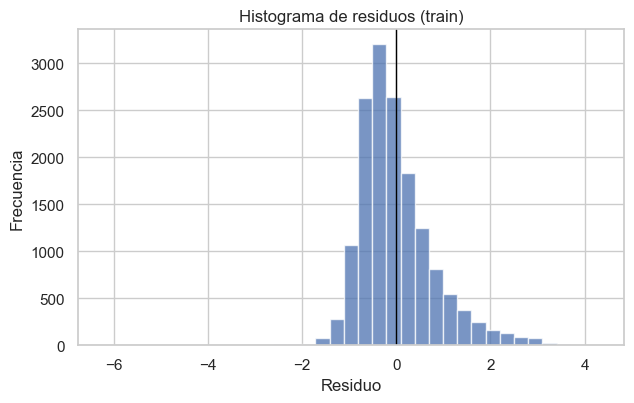

Validacion supuesto 1 (error medio cercano a 0):
- Media de residuos: 0.0000
- Mediana de residuos: -0.1630
- t-test H0: media(residuos)=0 -> t=0.0000, p=1
Interpretacion: no hay evidencia estadistica de sesgo global (cumple razonablemente).


In [79]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.hist(res_train, bins=35, alpha=0.75, edgecolor="white")
ax.axvline(0.0, color="black", linewidth=1)
ax.set_title("Histograma de residuos (train)")
ax.set_xlabel("Residuo")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

mean_res = float(np.mean(res_train))
median_res = float(np.median(res_train))
t_stat, p_value_mean0 = stats.ttest_1samp(res_train, popmean=0.0)

print("Validacion supuesto 1 (error medio cercano a 0):")
print(f"- Media de residuos: {mean_res:.4f}")
print(f"- Mediana de residuos: {median_res:.4f}")
print(f"- t-test H0: media(residuos)=0 -> t={t_stat:.4f}, p={p_value_mean0:.4g}")

if p_value_mean0 >= 0.05:
    print("Interpretacion: no hay evidencia estadistica de sesgo global (cumple razonablemente).")
else:
    print("Interpretacion: hay evidencia de sesgo global; revisar variables, grado o regularizacion.")

### Supuesto 2: varianza aproximadamente constante (homoscedasticidad)

Buscamos que la dispersion de residuos sea parecida en distintos niveles de prediccion. Si aparece efecto abanico, hay heteroscedasticidad.

**NOTA:** si no se cumple, se recomienda probar transformaciones de la variable objetivo (por ejemplo, log), usar errores robustos o emplear modelos/pesos que manejen heteroscedasticidad.

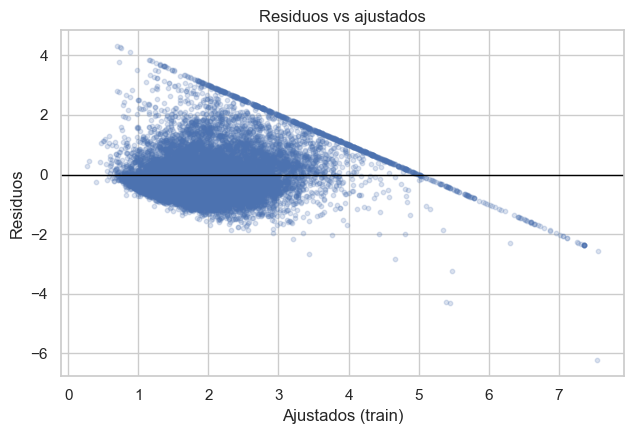

Validacion supuesto 2 (homoscedasticidad):
- Correlacion |residuo| vs ajustado: 0.1692
- Breusch-Pagan LM=234.7428, p=5.509e-53
Interpretacion: hay evidencia de heteroscedasticidad; considerar log(y) errores


In [80]:
from statsmodels.stats.diagnostic import het_breuschpagan

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(y_train_hat, res_train, alpha=0.2, s=10)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_xlabel("Ajustados (train)")
ax.set_ylabel("Residuos")
ax.set_title("Residuos vs ajustados")
plt.tight_layout()
plt.show()

# Prueba de Breusch-Pagan (H0: varianza constante)
X_bp = np.column_stack([np.ones(len(y_train_hat)), y_train_hat])
lm_stat, p_value_bp, f_stat, f_p_value_bp = het_breuschpagan(res_train, X_bp)

corr_abs = np.corrcoef(y_train_hat, np.abs(res_train))[0, 1]
print("Validacion supuesto 2 (homoscedasticidad):")
print(f"- Correlacion |residuo| vs ajustado: {corr_abs:.4f}")
print(f"- Breusch-Pagan LM={lm_stat:.4f}, p={p_value_bp:.4g}")

if p_value_bp >= 0.05:
    print("Interpretacion: no hay evidencia estadistica de heteroscedasticidad fuerte.")
else:
    print("Interpretacion: hay evidencia de heteroscedasticidad; considerar log(y) errores")

### Supuesto 3: normalidad aproximada de residuos

Se evalua con Q-Q plot y estadisticas de forma (asimetria y curtosis). Para prediccion no exige perfeccion, pero ayuda en la interpretacion inferencial.

**NOTA:** si no se cumple, para objetivos predictivos suele ser aceptable; para inferencia (intervalos/pruebas) conviene usar metodos robustos, bootstrap o reconsiderar transformaciones.

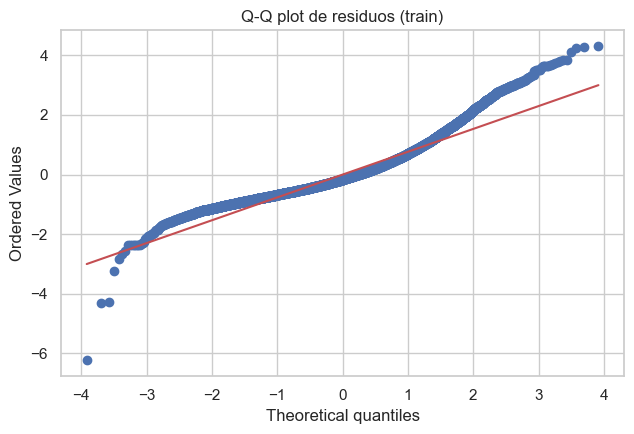

Validacion supuesto 3 (normalidad):
- Asimetria (skew): 1.1537
- Curtosis de exceso: 2.5818
- Jarque-Bera: JB=7733.4061, p=0
- Shapiro-Wilk (muestra): W=0.9223, p=4.582e-45
Interpretacion: hay desviaciones de normalidad; para enfoque predictivo no invalida el modelo, pero afecta inferencia clasica.


In [81]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
stats.probplot(res_train, dist="norm", plot=ax)
ax.set_title("Q-Q plot de residuos (train)")
plt.tight_layout()
plt.show()

skw = float(stats.skew(res_train))
krt = float(stats.kurtosis(res_train, fisher=True))
jb_stat, p_value_jb = stats.jarque_bera(res_train)

# Shapiro-Wilk puede ser sensible/tardado en muestras muy grandes
sample_for_shapiro = pd.Series(res_train).sample(n=min(5000, len(res_train)), random_state=42).values
shapiro_stat, p_value_shapiro = stats.shapiro(sample_for_shapiro)

print("Validacion supuesto 3 (normalidad):")
print(f"- Asimetria (skew): {skw:.4f}")
print(f"- Curtosis de exceso: {krt:.4f}")
print(f"- Jarque-Bera: JB={jb_stat:.4f}, p={p_value_jb:.4g}")
print(f"- Shapiro-Wilk (muestra): W={shapiro_stat:.4f}, p={p_value_shapiro:.4g}")

if p_value_jb >= 0.05 and p_value_shapiro >= 0.05:
    print("Interpretacion: residuos compatibles con normalidad aproximada.")
else:
    print("Interpretacion: hay desviaciones de normalidad; para enfoque predictivo no invalida el modelo, pero afecta inferencia clasica.")

### Supuesto 4: independencia aproximada de errores

Con datos no temporales y particion aleatoria, este supuesto suele evaluarse de forma exploratoria. Aqui revisamos autocorrelacion lag-1 de residuos ordenados por indice.

**NOTA:** si no se cumple, puede haber estructura temporal o espacial no modelada; se recomienda incorporar variables de contexto, terminos de rezago o modelos especificos para dependencia.

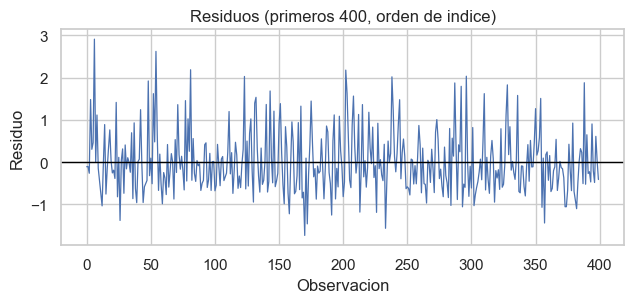

Validacion supuesto 4 (independencia de errores):
- Autocorrelacion lag-1: 0.0117
- Durbin-Watson: 1.9763 (cerca de 2 sugiere independencia)
- Ljung-Box lag 10: p=0.6202
Interpretacion: no hay evidencia fuerte de autocorrelacion en residuos.


In [82]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

res_series = pd.Series(res_train)
lag1_corr = float(res_series.autocorr(lag=1))

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(res_series.values[:400], linewidth=0.9)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_title("Residuos (primeros 400, orden de indice)")
ax.set_xlabel("Observacion")
ax.set_ylabel("Residuo")
plt.tight_layout()
plt.show()

dw_stat = float(durbin_watson(res_train))
lb_df = acorr_ljungbox(res_train, lags=[10], return_df=True)
p_value_lb = float(lb_df["lb_pvalue"].iloc[0])

print("Validacion supuesto 4 (independencia de errores):")
print(f"- Autocorrelacion lag-1: {lag1_corr:.4f}")
print(f"- Durbin-Watson: {dw_stat:.4f} (cerca de 2 sugiere independencia)")
print(f"- Ljung-Box lag 10: p={p_value_lb:.4g}")

if (1.5 <= dw_stat <= 2.5) and (p_value_lb >= 0.05):
    print("Interpretacion: no hay evidencia fuerte de autocorrelacion en residuos.")
else:
    print("Interpretacion: hay senales de dependencia; revisar estructura temporal/espacial o nuevas variables.")

### Conclusion integrada de supuestos (grafico + prueba estadistica)

En la siguiente celda se resume cada supuesto con su prueba formal, p-valor y una recomendacion accionable para clase.

> Regla didactica: si 2 o mas supuestos salen en "No cumple", conviene replantear variables, grado polinomial, regularizacion o usar metodos robustos.

In [83]:
alpha = 0.05

def decision_from_p(p):
    return "Cumple" if p >= alpha else "No cumple"

conclusions = pd.DataFrame(
    [
        {
            "supuesto": "Error medio = 0",
            "prueba": "t-test una muestra",
            "p_valor": float(p_value_mean0),
            "decision": decision_from_p(p_value_mean0),
            "accion_recomendada": "Si no cumple, revisar sesgo del modelo y variables omitidas.",
        },
        {
            "supuesto": "Homoscedasticidad",
            "prueba": "Breusch-Pagan",
            "p_valor": float(p_value_bp),
            "decision": decision_from_p(p_value_bp),
            "accion_recomendada": "Si no cumple, considerar log(y), WLS o errores robustos.",
        },
        {
            "supuesto": "Normalidad de residuos",
            "prueba": "Jarque-Bera",
            "p_valor": float(p_value_jb),
            "decision": decision_from_p(p_value_jb),
            "accion_recomendada": "Si no cumple, mantener enfoque predictivo y cautela en inferencia.",
        },
        {
            "supuesto": "Independencia de errores",
            "prueba": "Ljung-Box (lag 10)",
            "p_valor": float(p_value_lb),
            "decision": decision_from_p(p_value_lb),
            "accion_recomendada": "Si no cumple, modelar estructura temporal/espacial.",
        },
    ]
)

conclusions["p_valor"] = conclusions["p_valor"].map(lambda v: f"{v:.4g}")
display(conclusions)

n_no = int((conclusions["decision"] == "No cumple").sum())
print(f"Supuestos con 'No cumple': {n_no}/4")

if n_no == 0:
    print("Conclusion general: el modelo cumple razonablemente los supuestos revisados.")
elif n_no == 1:
    print("Conclusion general: hay un supuesto sensible; conviene ajuste menor y volver a validar.")
else:
    print("Conclusion general: hay varias alertas; conviene replantear especificacion del modelo.")

,supuesto,prueba,p_valor,decision,accion_recomendada
0,Error medio = 0,t-test una muestra,1,Cumple,"Si no cumple, revisar sesgo del modelo y varia..."
1,Homoscedasticidad,Breusch-Pagan,5.509e-53,No cumple,"Si no cumple, considerar log(y), WLS o errores..."
2,Normalidad de residuos,Jarque-Bera,0,No cumple,"Si no cumple, mantener enfoque predictivo y ca..."
3,Independencia de errores,Ljung-Box (lag 10),0.6202,Cumple,"Si no cumple, modelar estructura temporal/espa..."


Supuestos con 'No cumple': 2/4
Conclusion general: hay varias alertas; conviene replantear especificacion del modelo.
